In [1]:
from src.lib.new_drivers import *
from serial.tools import list_ports
import time
from matplotlib import pyplot as plt

In [ ]:
ports = list_ports.comports()
for port in ports:
    print(port.device)

In [2]:
port = "COM3"

elettrometro = ElettrometroKeithley(port)

def query(cmd):
    response = elettrometro.query(cmd)
    if response is not None and response != "":
        print(response)

query(elettrometro.commands["identify"])

KEITHLEY INSTRUMENTS INC.,MODEL 6517A,0776906,C02  /A02


In [3]:
elettrometro.reset()
time.sleep(0.1)
elettrometro.set_zero_check(False)
time.sleep(0.1)


In [ ]:
for i in range(-5,5):
    elettrometro.set_voltage(i)
    time.sleep(0.1)
#elettrometro.send_command(":SOUR:VOLT:LEV:IMM:AMPL 1")

In [4]:
elettrometro.send_command(elettrometro.commands["configure_charge"])
time.sleep(0.1)
elettrometro.send_command(elettrometro.commands["format_elements"])
time.sleep(0.1)


In [5]:
elettrometro.send_command("OUTP:STAT 1")

In [6]:
query(":SENS:CURR:DC:RANG:AUTO?")

1


In [ ]:
query(":SENS:CURR:DC:RANG:UPP?")

In [ ]:
elettrometro.send_command(f":SENS:CURR:DC:RANG:AUTO {1}")

In [ ]:
elettrometro.send_command(f":SENS:CURR:DC:RANG:UPP {1e-6}")

In [ ]:
print(elettrometro.get_fresh_reading())

In [ ]:
query(elettrometro.commands["identify"])

In [ ]:
elettrometro.send_command(":CALC:FORM NONE")

In [ ]:
query(":CALC:FORM?")

In [ ]:
currents=[]
times=[]
voltages=[]


vs = np.arange(0.1, , step=0.1)

print(f"Leggendo {len(vs)} volte, con tensioni tra {np.min(vs):.2f} e {np.max(vs):.2f}")

for v in vs:
    elettrometro.set_voltage(v)
    t=elettrometro.get_fresh_reading()
    corrente, tempo=elettrometro.parse_resistance_reading(t)
    currents.append(corrente)
    times.append(tempo)
    voltages.append(v)
    print(f"V={v:.2f}", end = ",")
    #time.sleep(0.2)

elettrometro.set_voltage(0)
elettrometro.get_fresh_reading()
currents=np.array(currents)
voltages=np.array(voltages)


Leggendo 100 volte, con tensioni tra -5.00 e 4.90
V=-5.00,V=-4.90,V=-4.80,V=-4.70,V=-4.60,V=-4.50,V=-4.40,V=-4.30,V=-4.20,V=-4.10,V=-4.00,V=-3.90,V=-3.80,V=-3.70,V=-3.60,V=-3.50,V=-3.40,V=-3.30,V=-3.20,V=-3.10,V=-3.00,V=-2.90,V=-2.80,V=-2.70,V=-2.60,V=-2.50,V=-2.40,V=-2.30,V=-2.20,V=-2.10,V=-2.00,V=-1.90,V=-1.80,V=-1.70,V=-1.60,V=-1.50,V=-1.40,V=-1.30,V=-1.20,V=-1.10,V=-1.00,V=-0.90,V=-0.80,V=-0.70,V=-0.60,V=-0.50,V=-0.40,V=-0.30,V=-0.20,V=-0.10,V=-0.00,V=0.10,V=0.20,V=0.30,V=0.40,V=0.50,V=0.60,V=0.70,V=0.80,V=0.90,V=1.00,V=1.10,V=1.20,V=1.30,V=1.40,V=1.50,V=1.60,V=1.70,V=1.80,V=1.90,V=2.00,V=2.10,V=2.20,V=2.30,V=2.40,V=2.50,V=2.60,V=2.70,V=2.80,V=2.90,V=3.00,V=3.10,V=3.20,V=3.30,V=3.40,V=3.50,V=3.60,V=3.70,V=3.80,V=3.90,V=4.00,V=4.10,V=4.20,V=4.30,V=4.40,V=4.50,V=4.60,V=4.70,V=4.80,V=4.90,

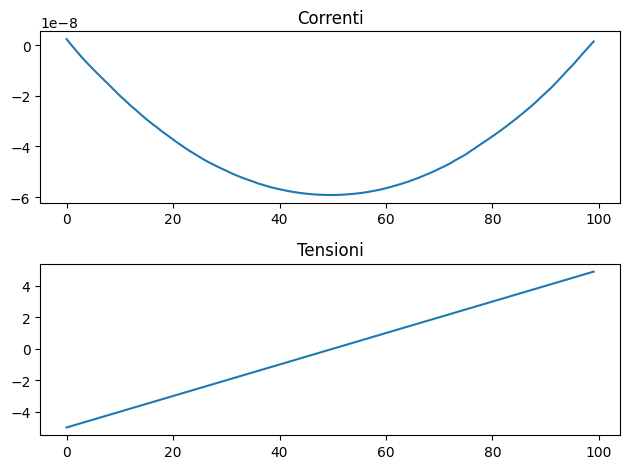

In [8]:
plt.subplot(2, 1, 1)

plt.plot(currents)
plt.title("Correnti")

plt.subplot(2, 1, 2)

plt.plot(voltages)
plt.title("Tensioni")

plt.tight_layout()
plt.show()

In [9]:
res=voltages/currents

[print(f"{r}, ", end="") for r in res]
print()

mo = np.log10(np.mean(res))
print(f"Resistenza media: {np.mean(res)/10**np.floor(mo):.2f} * 10^{int(np.floor(mo))}")


-2049684348.610314, 39484286865.43111, 1825303266.5323043, 924578038.3208091, 629955766.149464, 475079443.8403312, 379503368.092392, 314608056.89284325, 267631840.5424007, 229906971.78873247, 200793132.87485585, 178886773.8458365, 159765229.20003888, 144705914.56093505, 131150407.65918398, 119546134.56112924, 109967947.57763271, 101510038.72761798, 93614606.2189355, 86886573.78211668, 80547075.7384155, 74820559.65778643, 69614682.73108365, 64855516.32197181, 60628107.19049372, 56570685.07099641, 52808882.45402897, 49400535.24406032, 46197911.85438439, 43178070.47483562, 40320629.646952786, 37552895.229398996, 34927109.06377906, 32469020.734334875, 30114189.241329692, 27852670.51404912, 25620519.840347793, 23519790.999518987, 21466482.77046451, 19491519.417097498, 17568548.08248107, 15691689.68114512, 13846268.344142335, 12044564.89009361, 10268328.538594635, 8521371.599973004, 6794424.4952594675, 5082221.879643104, 3382543.7066931585, 1689623.0113140098, 3.001114783772655e-07, -1690671

-201184896230115.88 -14867352.177220594 -0.25470789218209017


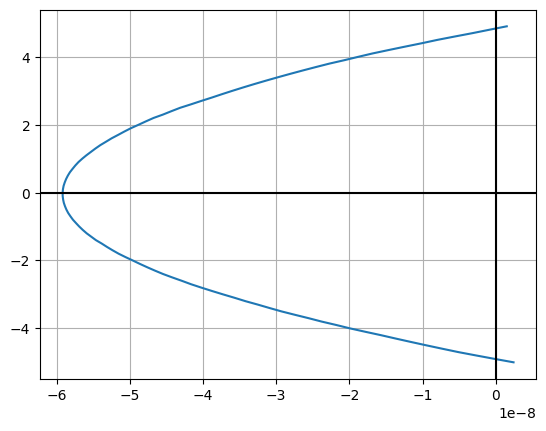

In [11]:

a,b, c=np.polyfit(currents,voltages,2)
plt.plot(currents,voltages)
plt.axvline(0, color="k")
plt.axhline(0, color="k")
plt.grid()
print(a,b, c)
plt.show()

In [ ]:
elettrometro.close()